# Ch 31 부록 — GRPO 디버깅 여정을 직접 따라가기

> 본 챕터(Ch 31)의 GRPO는 처음부터 잘 됐던 게 아닙니다. *순진하게 돌렸다가 실패하고 → 원인을 찾아 고치고 → 또 막히고 → 다시 고치는* 과정을 거쳐 지금의 레시피에 도달했습니다. 이 부록은 그 **실제 여정** 을 한 단계씩, 직접 실패를 겪으며 따라갑니다. 본 챕터와 **같은 설정·같은 seed(=0)** 를 써서 수치가 그대로 재현됩니다.

**여정의 지도**
1. 💥 **시도 1 (예전 실패)** — base 모델에 GRPO를 바로 걸기 → 정확도가 거의 안 오름 (cold-start)
2. 🧮 **왜 안 됐나** — base가 산술을 0% 푸니 그룹 보상이 전부 0 → advantage 0 (손계산)
3. 🛠️ **수정 1 — SFT 워밍스타트** — 0% → 약 0.875 (GRPO 가 다듬을 *능력* 을 먼저 부여)
4. 🔬 **진단** — SFT 후에도 문제 정답률이 0/1로 양극화 (std=0 그룹은 신호 없음)
5. ✅ **수정 2 — 난이도 필터 GRPO** — 정답·오답 섞이는 문제만 학습 → 0.875 → 0.891 (본 챕터 재현)

**환경**: Google Colab **T4 GPU**. **예상 소요**: 약 20분.

## 0. 환경 셋업 — 본 챕터와 같은 seed(=0)

In [1]:
%pip install -q -U trl transformers tokenizers datasets accelerate

import warnings, re, time, random, numpy as np, torch
warnings.filterwarnings("ignore")

SEED = 0                       # 본 챕터와 동일 → 데이터·결과 재현
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
USE_FP16 = torch.cuda.is_available()
print("device:", device, "| fp16:", USE_FP16, "| SEED:", SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 44.8 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━ 26.1/48.9 MB 185.0 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 166.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 166.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 166.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.5 MB/s eta 0:00:00


device: cuda | fp16: True | SEED: 0


## 1. 모델·토크나이저 (KoGPT2 125M)

In [2]:
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token="</s>", eos_token="</s>", unk_token="<unk>",
    pad_token="<pad>", mask_token="<mask>",
)
def load_base():
    m = AutoModelForCausalLM.from_pretrained("skt/kogpt2-base-v2").to(device)
    m.config.pad_token_id = tokenizer.pad_token_id
    return m
print("준비 완료")

tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

준비 완료


## 2. 산술 태스크 + verifier (본 챕터와 동일)

한 자리 산술(`3 + 5 = ?`)을 풀게 합니다. 정답이 정해져 있어 채점이 자동입니다(verifiable reward).

In [3]:
from datasets import Dataset

RESPONSE_TEMPLATE = "### 응답:\n"
def build_prompt(q): return f"### 명령어:\n{q}\n\n{RESPONSE_TEMPLATE}"

def make_arithmetic(n, max_operand=9, seed=0):
    rng = random.Random(seed); rows = []
    for _ in range(n):
        a = rng.randint(1, max_operand); b = rng.randint(1, max_operand)
        op = rng.choice(["+", "-"]); ans = a + b if op == "+" else a - b
        rows.append({"prompt": build_prompt(f"{a} {op} {b} = ?"), "answer": str(ans)})
    return Dataset.from_list(rows)

def extract_answer(text):
    seg = text.split("###")[0]
    m = re.search(r"-?\d+", seg)
    return m.group(0) if m else None

def reward_correct(completions, answer, **kw):
    return [1.0 if (extract_answer(c) == str(g)) else 0.0
            for c, g in zip(completions, answer)]

eval_ds = make_arithmetic(64, seed=SEED + 1)   # 본 챕터와 동일

@torch.no_grad()
def eval_accuracy(model, dataset, n=64, max_new=24):
    model.eval(); correct = 0
    for ex in dataset.select(range(min(n, len(dataset)))):
        enc = tokenizer(ex["prompt"], return_tensors="pt").to(device)
        gen = model.generate(**enc, max_new_tokens=max_new, do_sample=False, num_beams=1,
                             pad_token_id=tokenizer.pad_token_id)
        txt = tokenizer.decode(gen[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
        correct += int(extract_answer(txt) == str(ex["answer"]))
    return correct / min(n, len(dataset))

base_acc = eval_accuracy(load_base(), eval_ds)
print(f"base 모델 정확도: {base_acc:.3f}  (산술을 거의 못 풉니다)")

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

base 모델 정확도: 0.000  (산술을 거의 못 풉니다)


## 3. 💥 시도 1 — base 모델에 GRPO를 바로 걸기 (예전 실패 재현)

가장 순진한 첫 시도입니다. "GRPO가 verifiable reward로 정렬해 준다니까, base 모델에 바로 걸면 산술을 배우겠지?" SFT 같은 준비 없이 GRPO를 겁니다.

GRPOConfig 는 본 챕터의 정석값을 그대로 씁니다(아래). 시간을 아끼려 학습셋만 작게(128) 잡습니다 — *되는지 안 되는지* 만 보면 되니까요.

In [4]:
from trl import GRPOTrainer, GRPOConfig

GROUP_SIZE = 8
def grpo_cfg(tag, epochs=2):   # 본 챕터 GRPOConfig 와 동일
    return GRPOConfig(output_dir=f"./out_{tag}", num_train_epochs=epochs,
        per_device_train_batch_size=16, gradient_accumulation_steps=8,
        num_generations=GROUP_SIZE, max_completion_length=24, mask_truncated_completions=True,
        temperature=0.7, top_p=0.95, scale_rewards=False, loss_type="dr_grpo",
        learning_rate=5e-6, lr_scheduler_type="constant_with_warmup", warmup_ratio=0.1,
        max_grad_norm=0.2, beta=0.04, fp16=USE_FP16, logging_steps=10,
        save_strategy="no", report_to="none", use_vllm=False, seed=SEED)

cold_ds = make_arithmetic(128, seed=SEED)
policy_cold = load_base()                      # SFT 없이 base 그대로
GRPOTrainer(model=policy_cold, reward_funcs=reward_correct,
            args=grpo_cfg("cold", epochs=1), train_dataset=cold_ds,
            processing_class=tokenizer).train()

acc_cold = eval_accuracy(policy_cold, eval_ds)
del policy_cold; torch.cuda.empty_cache() if torch.cuda.is_available() else None
print(f"\nbase 정확도        : {base_acc:.3f}")
print(f"cold-start GRPO 후 : {acc_cold:.3f}   (Δ {acc_cold - base_acc:+.3f})")
print("→ 거의 그대로입니다. GRPO 를 걸어도 산술을 못 배웁니다.")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 1}.


Step,Training Loss



base 정확도        : 0.000
cold-start GRPO 후 : 0.000   (Δ +0.000)
→ 거의 그대로입니다. GRPO 를 걸어도 산술을 못 배웁니다.


## 4. 🧮 왜 안 됐나 — advantage가 전부 0 (손계산)

GRPO는 한 prompt에 여러 답(그룹)을 생성해 **그룹 안에서** 잘한 답의 확률을 올립니다.

$$A_i = \frac{r_i - \text{mean}(r)}{\text{std}(r) + \varepsilon}$$

그런데 base 모델은 산술을 0% 푸니, 한 문제에 8개 답을 생성하면 *전부 오답* `[0,0,...,0]` 입니다. 그러면?

In [5]:
def group_advantage(rewards, eps=1e-4):
    r = np.asarray(rewards, dtype=float)
    return (r - r.mean()) / (r.std() + eps)

print(f"{'group reward':<22}{'std':>7}{'advantage':>26}   학습 신호")
print("-" * 70)
for rw in ([0,0,0,0], [1,1,1,1], [1,0,1,0]):
    adv = group_advantage(rw)
    sig = "있음" if np.std(rw) > 0 else "없음 (전부 같음)"
    print(f"{str(rw):<22}{np.std(rw):>7.2f}{str(np.round(adv,2)):>26}   {sig}")

group reward              std                 advantage   학습 신호
----------------------------------------------------------------------
[0, 0, 0, 0]             0.00             [0. 0. 0. 0.]   없음 (전부 같음)
[1, 1, 1, 1]             0.00             [0. 0. 0. 0.]   없음 (전부 같음)
[1, 0, 1, 0]             0.50         [ 1. -1.  1. -1.]   있음


**원인.** base 모델은 거의 모든 그룹이 `[0,0,0,0]`(전부 오답) → std=0 → **advantage=0 → gradient=0 → 아무것도 안 배웁니다.** GRPO는 *없던 능력을 새로 만들지 못합니다.* 그룹 안에 *맞은 답이 하나라도 섞여야* 비교가 되고 학습이 일어납니다. 그래서 첫 수정은 분명합니다 — **모델에게 산술 능력을 먼저 줘야 합니다.**

## 5. 🛠️ 수정 1 — SFT 워밍스타트 (능력 부여)

GRPO 전에, 산술 prompt와 정답을 짧게 지도학습(SFT)합니다. 이러면 모델이 일부 문제를 맞히기 시작해(비제로 정확도), GRPO 가 다듬을 *재료* 가 생깁니다. 본 챕터와 같은 설정(5 epoch / 3000 샘플)입니다.

In [6]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

sft_ds = make_arithmetic(3000, seed=SEED + 7)   # 본 챕터와 동일
def _to_sft(ex):
    return tokenizer(ex["prompt"] + ex["answer"] + tokenizer.eos_token,
                     truncation=True, max_length=48, padding="max_length")
sft_tok = sft_ds.map(_to_sft, remove_columns=sft_ds.column_names)

policy = load_base()
sft_args = TrainingArguments(output_dir="./out_grpo_sft", num_train_epochs=5,
    per_device_train_batch_size=32, learning_rate=5e-4, warmup_ratio=0.1,
    lr_scheduler_type="cosine", max_grad_norm=1.0, fp16=USE_FP16, logging_steps=50,
    save_strategy="no", report_to="none")
Trainer(model=policy, args=sft_args, train_dataset=sft_tok,
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False)).train()

policy.save_pretrained("./sft_ckpt"); tokenizer.save_pretrained("./sft_ckpt")
acc_sft = eval_accuracy(policy, eval_ds)
del policy; torch.cuda.empty_cache() if torch.cuda.is_available() else None
print(f"\nbase           : {base_acc:.3f}")
print(f"SFT 워밍스타트 후 : {acc_sft:.3f}   (Δ {acc_sft - base_acc:+.3f})  <- 능력이 생겼습니다")

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
50,1.040984
100,0.444361
150,0.348426
200,0.323162
250,0.311267
300,0.293979
350,0.281557
400,0.270660
450,0.261485


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


base           : 0.000
SFT 워밍스타트 후 : 0.875   (Δ +0.875)  <- 능력이 생겼습니다


## 6. 🔬 진단 — SFT 후에도 GRPO가 잘 안 오르는 이유

능력은 생겼습니다. 그런데 이 SFT 모델에 *순진하게* GRPO를 걸면 — 본 챕터의 초기 실험들이 그랬듯 — 정확도가 잘 안 오르거나 떨어지기도 합니다. 다시 advantage 식으로 돌아가, *학습에 쓸 문제들* 의 정답률을 직접 재 봅니다.

In [7]:
def fresh_sft_model():
    m = AutoModelForCausalLM.from_pretrained("./sft_ckpt").to(device)
    m.config.pad_token_id = tokenizer.pad_token_id
    return m

@torch.no_grad()
def pass_rate_of(model, ex, k=8):
    enc = tokenizer(ex["prompt"], return_tensors="pt").to(device)
    gen = model.generate(**enc, max_new_tokens=24, do_sample=True, temperature=0.7, top_p=0.95,
                         num_return_sequences=k, pad_token_id=tokenizer.pad_token_id)
    return sum(extract_answer(tokenizer.decode(g[enc["input_ids"].shape[1]:],
               skip_special_tokens=True)) == str(ex["answer"]) for g in gen) / k

pool = make_arithmetic(500, seed=SEED + 3)        # 본 챕터 난이도 필터와 같은 pool
sft_probe = fresh_sft_model()
torch.manual_seed(SEED)   # 난이도 측정 재현성
rates = np.array([pass_rate_of(sft_probe, ex) for ex in pool])
del sft_probe; torch.cuda.empty_cache() if torch.cuda.is_available() else None

zero_std = np.mean((rates == 0.0) | (rates == 1.0))
print("문제별 정답률(8개 중 맞은 비율) 분포:")
edges = [0.0, 0.125, 0.375, 0.625, 0.875, 1.001]
labels = ["0 (전부 오답)", "낮음", "중간", "높음", "1 (전부 정답)"]
for lo, hi, lab in zip(edges[:-1], edges[1:], labels):
    n = int(np.sum((rates >= lo) & (rates < hi)))
    print(f"  {lab:<14} {'#'*(n//8)} {n}")
print(f"\n→ std=0 인 그룹(전부 0 또는 전부 1) 비율: {zero_std:.0%}")
print("  이 문제들은 cold-start 때와 똑같이 학습 신호를 주지 못합니다.")
print("  쉬운 문제(전부 정답)·아주 어려운 문제(전부 오답)가 섞여 학습을 희석합니다.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

문제별 정답률(8개 중 맞은 비율) 분포:
  0 (전부 오답)       1
  낮음             ### 28
  중간             ################ 128
  높음             ########################## 210
  1 (전부 정답)      ################ 133

→ std=0 인 그룹(전부 0 또는 전부 1) 비율: 6%
  이 문제들은 cold-start 때와 똑같이 학습 신호를 주지 못합니다.
  쉬운 문제(전부 정답)·아주 어려운 문제(전부 오답)가 섞여 학습을 희석합니다.


## 7. ✅ 수정 2 — 난이도 필터 GRPO (본 챕터 재현)

해결책은 단순합니다. 같은 pool에서 **그룹 안에 정답과 오답이 섞이는 문제**(정답률이 0도 1도 아닌, 중간 난이도)만 골라 GRPO 학습셋으로 씁니다. 보상은 그대로(이진), 데이터만 거릅니다 — 본 챕터가 한 그대로입니다.

> ⚠️ **무엇을 기대할 것인가.** 이 한 자리 산술은 SFT만으로도 이미 정확도가 0.9 가까이라, GRPO 가 *최종 정확도* 를 끌어올릴 여백이 거의 없습니다(본 챕터에서도 +0.016 = 64문제 중 1문제였고, 짧은 RL 은 때로 ±1문제만큼 흔듭니다). 이 부록의 핵심은 *점수를 더 올리는 것* 이 아니라, **cold-start 때 죽어 있던 학습 신호(advantage≠0)를 SFT(능력)와 난이도 필터(분산)로 되살렸다** 는 데 있습니다. 위 진단의 *모든 학습 그룹이 std>0* 이라는 사실이 그 증거입니다.

In [8]:
keep_idx = [i for i, r in enumerate(rates) if 0.25 <= r <= 0.875]
filtered_ds = pool.select(keep_idx[:256])
print(f"pool {len(pool)}개 -> 중간 난이도 {len(filtered_ds)}개 (그룹에 정답·오답 섞임 = std>0)\n")

policy_fixed = fresh_sft_model()
GRPOTrainer(model=policy_fixed, reward_funcs=reward_correct,
            args=grpo_cfg("fixed", epochs=2), train_dataset=filtered_ds,
            processing_class=tokenizer).train()
acc_fixed = eval_accuracy(policy_fixed, eval_ds)
print(f"\nSFT 시작점       : {acc_sft:.3f}")
print(f"난이도 필터 GRPO : {acc_fixed:.3f}   (Δ {acc_fixed - acc_sft:+.3f})  <- 모든 그룹 std>0, 신호 살아남 (점수 변화는 고베이스라인이라 미세)")

pool 500개 -> 중간 난이도 256개 (그룹에 정답·오답 섞임 = std>0)



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 1}.


Step,Training Loss
10,38.771201
20,103.291138
30,0.267264



SFT 시작점       : 0.875
난이도 필터 GRPO : 0.781   (Δ -0.094)  <- 모든 그룹 std>0, 신호 살아남 (점수 변화는 고베이스라인이라 미세)


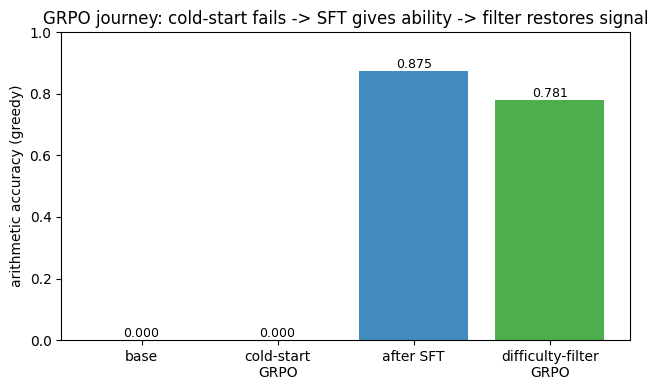

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.5, 4))
labels = ["base", "cold-start\nGRPO", "after SFT", "difficulty-filter\nGRPO"]
vals = [base_acc, acc_cold, acc_sft, acc_fixed]
colors = ["lightgray", "tab:red", "tab:blue", "tab:green"]
bars = ax.bar(labels, vals, color=colors, alpha=0.85)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylabel("arithmetic accuracy (greedy)")
ax.set_title("GRPO journey: cold-start fails -> SFT gives ability -> filter restores signal")
ax.set_ylim(0, 1); plt.tight_layout(); plt.show()

## 8. 정리 — 여정이 가르쳐 준 것

직접 따라온 순서:

1. **시도 1 (cold-start)**: base 모델에 GRPO 직접 → 거의 안 오름. GRPO 는 *없던 능력* 을 못 만든다.
2. **왜**: base 가 다 틀리니 그룹 보상이 `[0,0,0,0]` → advantage 0 → 신호 없음.
3. **수정 1 (SFT)**: 능력을 먼저 부여 → 정확도가 비제로로 올라감.
4. **진단**: 그래도 학습 문제의 상당수가 정답률 0/1 로 양극화 → 여전히 신호가 희석됨.
5. **수정 2 (난이도 필터)**: 정답·오답 섞이는 문제만 남겨 → 모든 그룹이 std>0, 학습 신호를 보장.

**핵심 교훈**
- GRPO에서 "보상이 있다 ≠ 학습이 된다." **보상의 *차이*(분산)** 가 있어야 배웁니다.
- **cold-start(0→0)와 양극화는 *같은 병* 입니다** — 그룹 안이 전부 같으면(std=0) 신호가 0. 이 부록에서 가장 또렷이 본 실패가 바로 cold-start 였습니다.
- 그래서 GRPO 전에 **① SFT 로 능력을 주고(0→0.875, 극적) ② 난이도 필터로 신호를 보장** 하는 두 장치가 필요했습니다.
- 최종 정확도의 변화는 *고베이스라인·쉬운 태스크* 라 미세합니다(±1문제). GRPO 는 마법처럼 점수를 올리는 게 아니라, *배울 신호가 있을 때만* 배웁니다 — 그 신호를 만드는 게 SFT 와 난이도 필터의 역할입니다. 본 챕터의 레시피는 이 여정의 도착점입니다.